# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells within the same brain section;
- Niche: all neighboring cells within the same brain section;
- Niche: cross brain section k-hop neighbouring cells;
- Positive pairs: samples from the same brain section and visualization by prob.

## Load Data

In [1]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## QueST Embedding

In [2]:
# load data
import numpy as np
import pandas as pd
import torch
import os
import scanpy as sc


def load_emb(adata_folder, emb_folder, emb_key, suffix='pt', update_anndata=True):
    adata_list = []
    fnames = [fname for fname in os.listdir(adata_folder)]
    fnames.sort()
    for fname in fnames:
        if not fname.endswith(".h5ad"):
            continue
        stem = fname.replace(".h5ad", "")
        adata_path = os.path.join(adata_folder, fname)
        adata = sc.read_h5ad(adata_path)
        if embedding_key in adata.obsm:
            print(f"[SKIP] embedding exists for {fname}")
            continue

        emb_path = os.path.join(emb_folder, f"{stem}.{suffix}")
        if not os.path.exists(emb_path):
            print(f"[SKIP] No embedding for {fname}")
            continue
        print(f"[LOAD] {emb_path}")
        if suffix == 'csv':
            emb = pd.read_csv(emb_path, index_col=0).values.astype(np.float64)
        elif suffix == 'pt':
            emb_tensor = torch.load(emb_path, map_location="cpu")
            emb = emb_tensor.detach().cpu().numpy()
        else:
            print(f"[SKIP] not supported suffix {fname}")
            continue

        # -------- sanity checks --------
        if emb.ndim != 2:
            raise ValueError(f"{emb_path} embedding must be 2D, got {emb.shape}")
        if emb.shape[0] != adata.n_obs:
            raise ValueError(
                f"Cell number mismatch for {stem}: "
                f"embedding {emb.shape[0]} vs adata {adata.n_obs}"
            )

        adata.obsm[emb_key] = emb
        adata_list.append(adata)
        if update_anndata:
            adata.write_h5ad(adata_path)
        print(f"[DONE] {stem}")
    return adata_list


adata_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/notebook/ccf/data/benchmark_samples/20260329_224339'
emb_folder = '/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/exploration/QueST/output/embeddings/quest_zhuang_abca_1_0329'
embedding_key = 'X_quest_emb'
adata_list = load_emb(adata_folder, emb_folder, emb_key=embedding_key, suffix='pt')

[SKIP] embedding exists for Zhuang-ABCA-1.084.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.086.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.087.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.088.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.090.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.093.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.096.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.097.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.102.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.104.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.106.h5ad
[SKIP] embedding exists for Zhuang-ABCA-1.107.h5ad


In [3]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery
import os

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
target_sample_ids = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
                  'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
                  'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
target_sample_ids.sort()
adata_paths = [os.path.join(adata_folder, sample_id) for sample_id in target_sample_ids ]
db = Database(target_sample_ids)
db.construct(adata_path=adata_paths,
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name=embedding_key,
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
INFO:src.NicheQueryPrototype.database:Constructing parcellation tree...
INFO:src.NicheQueryPrototype.database:Loading AnnData...
INFO:src.NicheQueryPrototype.database:Subset 'Zhuang-ABCA-1.084' to 27806 / 27806 cells (from ``target_sample_ids`` metadata).
INFO:src.NicheQueryPrototype.database:Subset 'Zhuang-ABCA-1.086' to 29822 / 29822 cells (from ``target_sample_ids`` metadata).
INFO:src.NicheQueryPrototype.database:Subset 'Zhuang-ABCA-1.087' to 28737 / 28737 cells (from ``target_sample_ids`` metadata).
INFO:src.NicheQueryPrototype.database:Sub

INFO:src.NicheQueryPrototype.database:Highlighted cells (n=11281) for parcellation 688 in sample 'Zhuang-ABCA-1.086':
INFO:src.NicheQueryPrototype.database:  cell_id='104033803221008912425495456606967230629'  x=5.794704030577987  y=5.9825911152527045  parcellation_index=121
INFO:src.NicheQueryPrototype.database:  cell_id='107553668284574284148107516441567804938'  x=5.824668742314688  y=5.977184826102871  parcellation_index=121
INFO:src.NicheQueryPrototype.database:  cell_id='154266547422647571694824065249881359245'  x=5.769363525260687  y=5.79255243202174  parcellation_index=113
INFO:src.NicheQueryPrototype.database:  cell_id='202486533939372132505472680784048526464'  x=5.776840409646431  y=5.922804523661706  parcellation_index=216
INFO:src.NicheQueryPrototype.database:  cell_id='265780475189590563644137526415384959663'  x=5.829550622880749  y=5.862091841910367  parcellation_index=1086
INFO:src.NicheQueryPrototype.database:  cell_id='35143606473898951294819219390152679788'  x=5.7993638

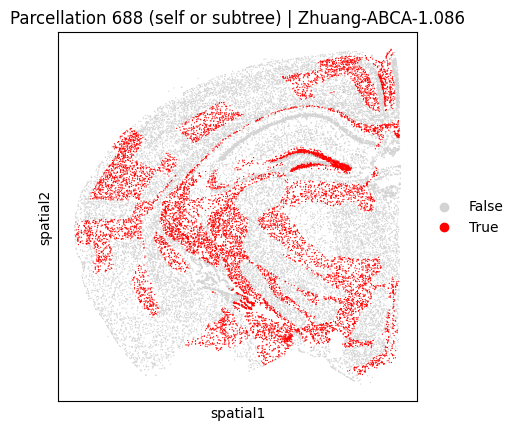

In [4]:
target_parcellation = 688

db.get_sample("Zhuang-ABCA-1.086").visualize_parcellation_cells(
    target_parcellation_index=target_parcellation,
    print_metadata=True,
    spot_size=0.02,
    metadata_txt_path='notebook/ccf/data/benchmark_samples/sample_cells/Zhuang-ABCA-1.086_parcellation_688.txt'
)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.086 slice.
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.086')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:171: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


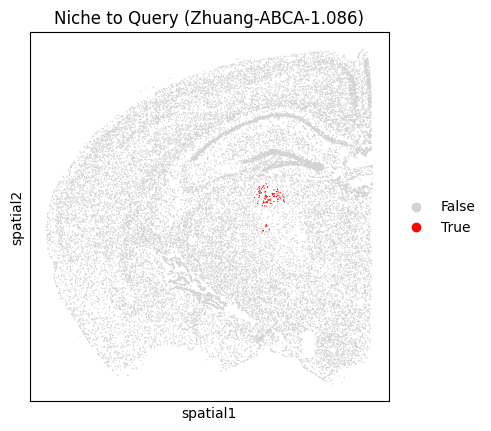

In [5]:
# step 2: construct niche to query;
target_parcellation = 688
niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='204536562932209937938079562580281173940', sample_id='Zhuang-ABCA-1.086', \
    k=8, cell_limit=100, parcellation_index=target_parcellation)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

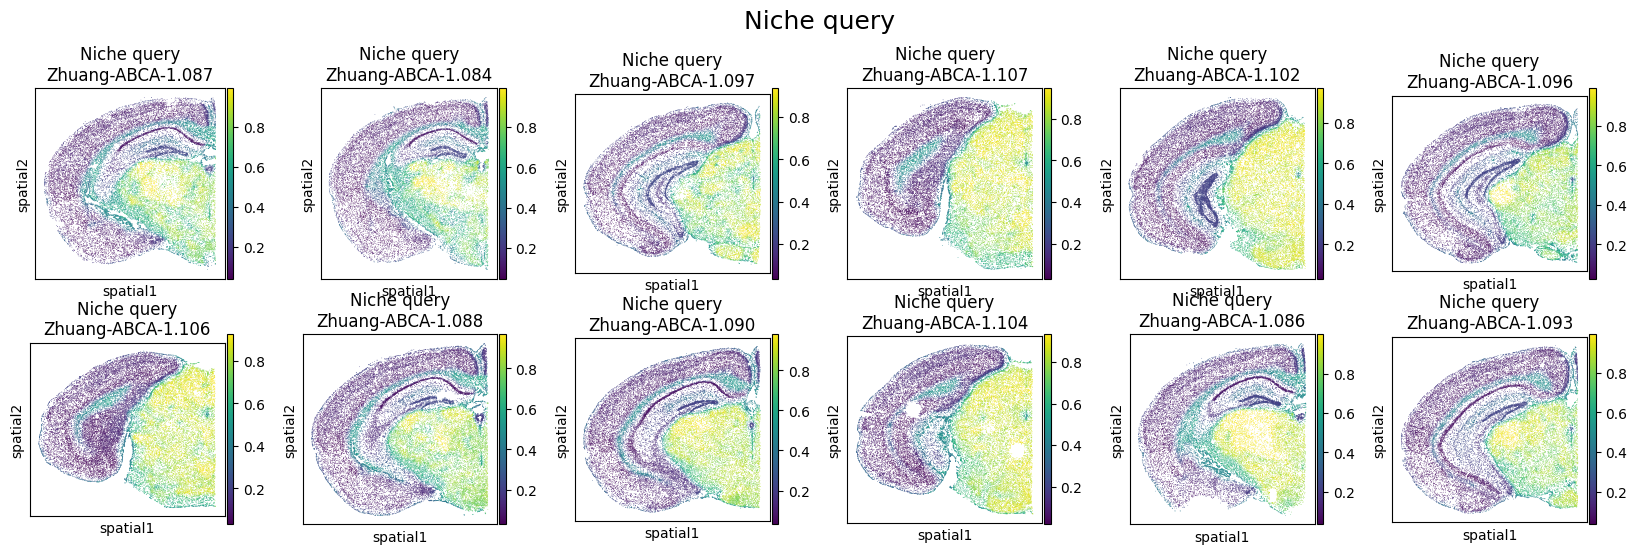

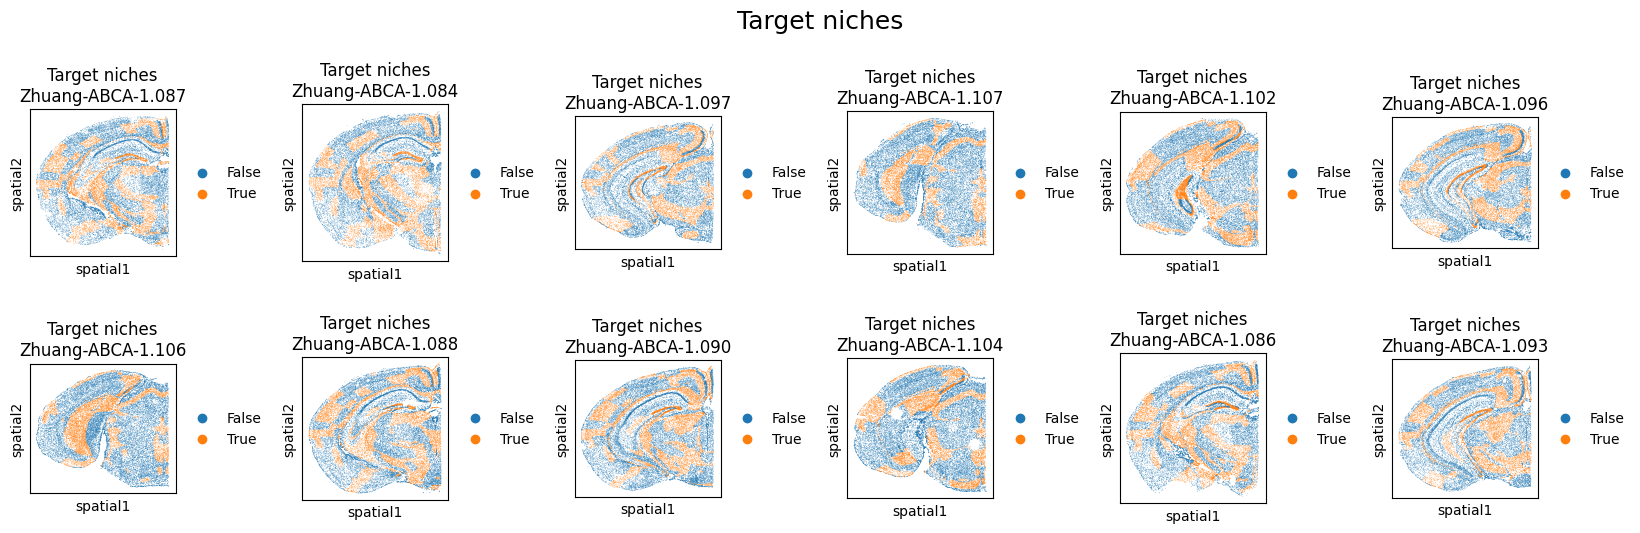

In [6]:
# step 3: run niche query on given samples
import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [7]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260329_224339/quantitive_metrics/quest.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

KeyboardInterrupt: 

## Gene Expressions

In [2]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
zhuang_abca_1_folder = 'notebook/ccf/data/zhuang-abca-1/'
zhuang_abca_2_folder = 'notebook/ccf/data/zhuang-abca-2/'
zhuang_abca_3_folder = 'notebook/ccf/data/zhuang-abca-3/'
zeng_mwb_folder = 'notebook/ccf/data/zeng-mwb/'
sample_data_folder = 'notebook/ccf/data/benchmark_samples/20260414_235933'

target_sample_ids = [
    'Zhuang-ABCA-1.098', 'Zhuang-ABCA-1.099', 'Zhuang-ABCA-1.097', #'Zhuang-ABCA-1.096',
    #'Zhuang-ABCA-2.046', 'Zhuang-ABCA-2.047', 'Zhuang-ABCA-2.048', #'Zhuang-ABCA-2.050',
    #'Zhuang-ABCA-3.001', 'Zhuang-ABCA-3.002', 'Zhuang-ABCA-3.004', #'Zhuang-ABCA-3.005',
    'C57BL6J-638850.28', 'C57BL6J-638850.29', 'C57BL6J-638850.30', #'C57BL6J-638850.31'
]

db = Database(target_sample_ids)

db.construct(
    adata_path=[
        sample_data_folder + '/' + sample_id + '.h5ad'
        for sample_id in target_sample_ids
    ],
    cell_metadata_path=[
        zhuang_abca_1_folder + 'cell_metadata.csv',
        zhuang_abca_2_folder + 'cell_metadata.csv',
        zhuang_abca_3_folder + 'cell_metadata.csv',
        zeng_mwb_folder + 'cell_metadata.csv',
    ],
    ccf_coordinates_path=[
        zhuang_abca_1_folder + 'ccf_coordinates.csv',
        zhuang_abca_2_folder + 'ccf_coordinates.csv',
        zhuang_abca_3_folder + 'ccf_coordinates.csv',
        zeng_mwb_folder + 'ccf_coordinates.csv',
    ],
    feature_name='gene_expression',
    parcellation_path='notebook/ccf/data/parcellation/structure.json'
)


/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Loading CCF coordinates...
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunksize=_METADATA_CSV_CHUNKSIZE):
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/database.py:361: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(path, chunk

In [ ]:
# (optional) export sample slices
# db.export_sample_adata('notebook/ccf/data/benchmark_samples')

INFO:src.NicheQueryPrototype.database:Highlighted cells (n=583) for parcellation 207 in sample 'Zhuang-ABCA-1.098':
INFO:src.NicheQueryPrototype.database:  cell_id='108395091855643956884780052311839360855'  x=5.196008020449033  y=4.338481068877207  parcellation_index=207
INFO:src.NicheQueryPrototype.database:  cell_id='114628682732609099405315094388416707757'  x=5.2267765361602025  y=4.314879178637211  parcellation_index=207
INFO:src.NicheQueryPrototype.database:  cell_id='116989095859802443657276862480948145389'  x=5.330616785106029  y=4.302350717442807  parcellation_index=207
INFO:src.NicheQueryPrototype.database:  cell_id='134840808460519879735625431844364573300'  x=5.307047660298572  y=4.256978847824072  parcellation_index=207
INFO:src.NicheQueryPrototype.database:  cell_id='135815520852954369042806337923633344942'  x=5.202477057082086  y=4.343412065316104  parcellation_index=207
INFO:src.NicheQueryPrototype.database:  cell_id='161536579035926513231781703223392965523'  x=5.27887569

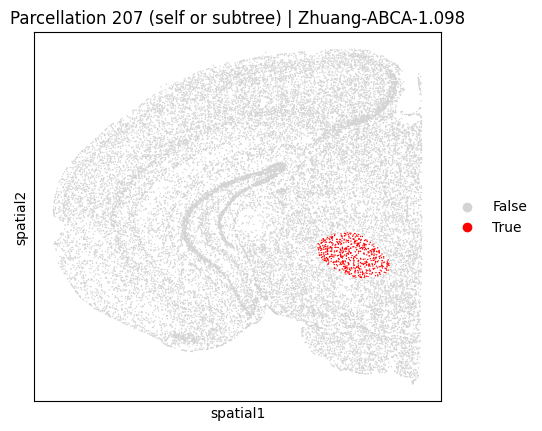

In [3]:
target_parcellation = 207
query_niche_sample_id = 'Zhuang-ABCA-1.098'

db.get_sample(query_niche_sample_id).visualize_parcellation_cells(
    target_parcellation_index=target_parcellation,
    print_metadata=True,
    spot_size=0.02,
    metadata_txt_path=f'notebook/ccf/data/benchmark_samples/center_cells/{query_niche_sample_id}_parcellation_207.txt'
)

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.098 slice.
INFO:src.NicheQueryPrototype.niche:Niche contains 100 cell(s) (sample_id='Zhuang-ABCA-1.098')
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:171: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


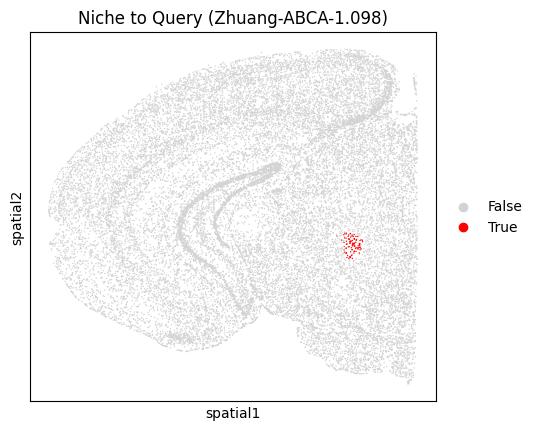

In [4]:
# step 2: construct niche to query;

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='267504471830606554974249492302877563377', sample_id=query_niche_sample_id, \
    k=8, cell_limit=100, parcellation_index=target_parcellation)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr

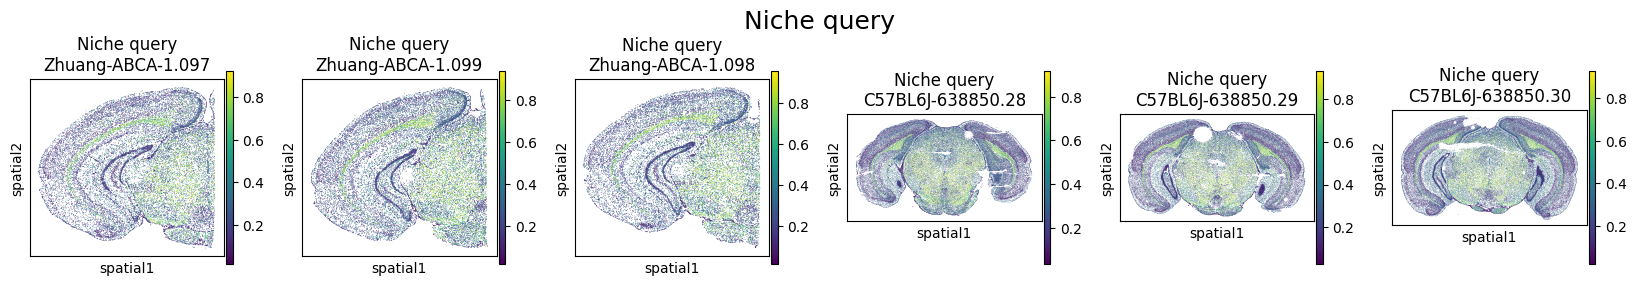

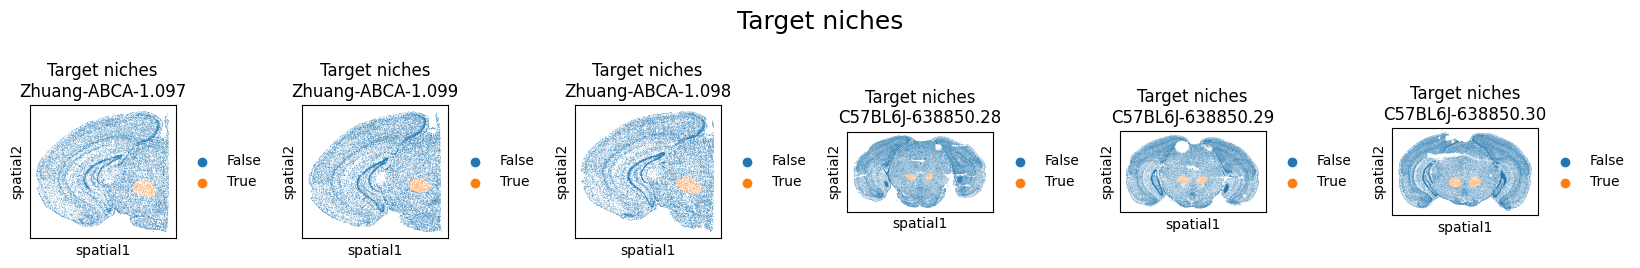

In [5]:
# step 3: run niche query on given samples

import matplotlib.pyplot as plt
import scanpy as sc

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)


In [ ]:
# step 4: classification report
niche_query.niche_query_quantitive_metrics(search_samples=query_samples, \
    result_txt_path='notebook/ccf/data/benchmark_samples/20260414_235933/quantitive_metrics/raw_gene_expression.txt')

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.099
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.098
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.28
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: C57BL6J-638850.29
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample C57BL6J-638850.30
INFO:sr